# 04 — Standardised Approach EAD and CCF

## Turning balances and limits into EAD

Classification is complete. This notebook converts contractual balances and commitments into Standardised Approach Exposure at Default for every loan.

EAD is the rupee amount to which the Standardised Approach risk weight is applied. Understating undrawn exposure would understate RWA and overstate capital ratios.

### Words used in the EAD calculation

| Term | Simple meaning |
|---|---|
| CCF | Credit Conversion Factor, the percentage of committed undrawn exposure included in EAD |
| Funded exposure | outstanding balance plus accrued interest |
| Converted undrawn | CCF multiplied by the undrawn amount |
| CRM | Credit Risk Mitigation recognised after pre-CRM EAD is calculated |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display as notebook_display
from pandas.io.formats.style import Styler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from basel_credit_risk.config import load_all_config

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)


def display(*objects, **kwargs):
    # Show complete table text and wrap long descriptions in saved notebook output.
    wrapped_objects = []
    for displayed_object in objects:
        if isinstance(displayed_object, pd.DataFrame):
            displayed_object = displayed_object.style
        if isinstance(displayed_object, Styler):
            displayed_object = displayed_object.set_properties(**{
                "white-space": "normal",
                "overflow-wrap": "anywhere",
                "text-align": "left",
                "vertical-align": "top",
                "max-width": "420px",
            }).set_table_styles([
                {"selector": "table", "props": [("width", "100%"), ("table-layout", "auto")]},
                {"selector": "th", "props": [
                    ("white-space", "normal"),
                    ("overflow-wrap", "anywhere"),
                    ("word-break", "break-word"),
                    ("text-align", "left"),
                    ("vertical-align", "top"),
                    ("max-width", "180px"),
                ]},
            ], overwrite=False)
        wrapped_objects.append(displayed_object)
    return notebook_display(*wrapped_objects, **kwargs)

configs = load_all_config(ROOT / "config")
raw = pd.read_csv(ROOT / "data/generated/current_portfolio.csv.gz", low_memory=False)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)

print(f"Portfolio represented below: {len(loans):,} synthetic loan-level exposures")

Portfolio represented below: 30,000 synthetic loan-level exposures


## Basel CCF reference table used by the engine

The contract category selects the CCF. Broad product names do not select it. Most term loans have no undrawn commitment. A revolving facility can be unconditionally cancellable or another commitment, producing a different conversion.

In [2]:
ccf_table = pd.DataFrame(configs["ccf_parameters"]["rules"]).T.reset_index()
ccf_table = ccf_table.rename(columns={"index": "Commitment type", "ccf": "CCF", "rule_id": "Rule ID", "basel_reference": "Basel reference"})
display(ccf_table)

,Commitment type,CCF,Rule ID,Basel reference
0,no_commitment,0.000000,CCF_NO_UNDRAWN_COMMITMENT,CRE20.94
1,unconditionally_cancellable,0.100000,CCF_UCC_10,CRE20.97
2,short_term_trade_letter,0.200000,CCF_TRADE_20,CRE20.96
3,other_commitment,0.400000,CCF_COMMITMENT_40,CRE20.95
4,transaction_related_contingent,0.500000,CCF_TRANSACTION_50,CRE20.95
5,direct_credit_substitute,1.000000,CCF_SUBSTITUTE_100,CRE20.95


A 40% CCF means 40% of the unused commitment enters EAD. It does not mean a 40% probability of default or a 40% loss. The CCF measures potential additional drawing before default.

## One revolving-loan calculation

The example selects a loan with an undrawn amount and displays every term in `EAD = outstanding + accrued interest + CCF × undrawn`.

In [3]:
revolving_example = loans.loc[loans["undrawn_amount"].gt(0)].iloc[0]
manual_ead = (
    revolving_example["outstanding_balance"]
    + revolving_example["accrued_interest"]
    + revolving_example["ccf"] * revolving_example["undrawn_amount"]
)
display(pd.Series({
    "Product": revolving_example["product_type"],
    "Commitment type": revolving_example["commitment_type"],
    "Outstanding (INR crore)": revolving_example["outstanding_balance"] / CRORE,
    "Accrued interest (INR crore)": revolving_example["accrued_interest"] / CRORE,
    "Undrawn (INR crore)": revolving_example["undrawn_amount"] / CRORE,
    "CCF": revolving_example["ccf"],
    "Converted undrawn (INR crore)": revolving_example["converted_undrawn"] / CRORE,
    "EAD before CRM (INR crore)": revolving_example["ead_pre_crm"] / CRORE,
}).to_frame("Value"))
assert np.isclose(manual_ead, revolving_example["ead_pre_crm"])

,Value
Product,corporate_revolver
Commitment type,other_commitment
Outstanding (INR crore),30.558323
Accrued interest (INR crore),0.006469
Undrawn (INR crore),8.739060
CCF,0.400000
Converted undrawn (INR crore),3.495624
EAD before CRM (INR crore),34.060416


The calculated EAD is larger than the current balance because the facility can be drawn further. That full EAD now becomes the exposure base for the risk-weight rules.

## Where converted undrawn exposure matters

The stacked chart separates funded exposure from the CCF-converted undrawn amount by product. A visible second section identifies products whose current balances do not capture all potential exposure.

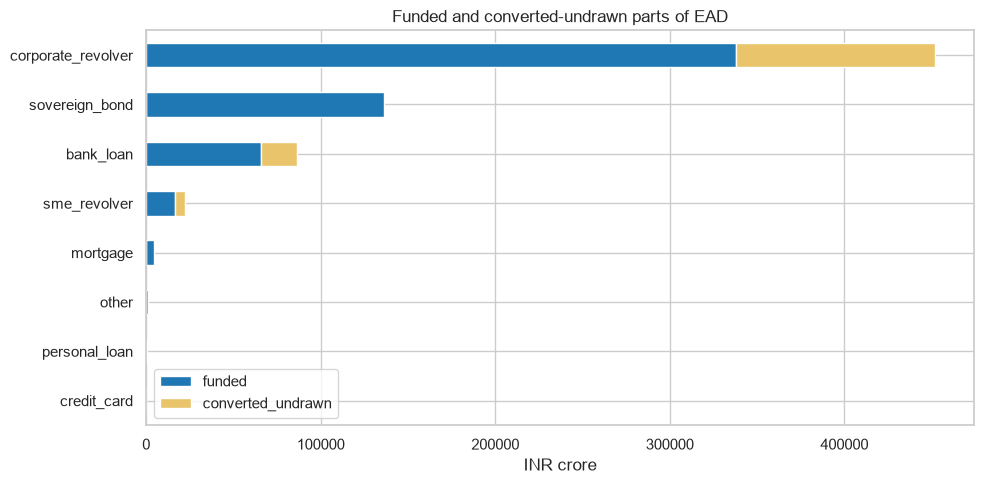

In [4]:
ead_parts = loans.groupby("product_type").agg(
    funded=("funded_exposure", "sum"),
    converted_undrawn=("converted_undrawn", "sum"),
).sort_values("funded") / CRORE
ead_parts.plot.barh(stacked=True, figsize=(10, 5), color=[COLORS[1], COLORS[3]], title="Funded and converted-undrawn parts of EAD")
plt.xlabel("INR crore")
plt.ylabel("")
plt.tight_layout()
plt.show()

Corporate and SME revolvers can produce large converted-undrawn exposure even when they are fewer in number. Credit cards can be numerous but small. The risk weight applied next acts on the combined EAD, not only on the current balance.

Every loan has a funded amount, commitment type, CCF, converted undrawn amount and Standardised Approach EAD before CRM.